In [86]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [87]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


##Aim

The aim of this project is to determine whether social intervention increases the probability for guests to reuse their towels by looking at 7 different studies. Hierchical modelling is used to account for the differences between the studies.

Firstly, the data is prepared and visualised.

In [88]:
data = pd.read_csv('/content/gdrive/MyDrive/towelData.csv', sep=';', encoding='latin1')

count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set
# can give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')

print(combined_data)


    reuse  total    group study
0      74    211  control     1
1     103    277  control     2
2      77    135  control     3
3      82    187  control     4
4      21     25  control     5
5     123    147  control     6
6      28     30  control     7
7      98    222   social     1
8     587   1318   social     2
9     406    655   social     3
10    278    555   social     4
11     21     24   social     5
12    472    576   social     6
13    101    132   social     7


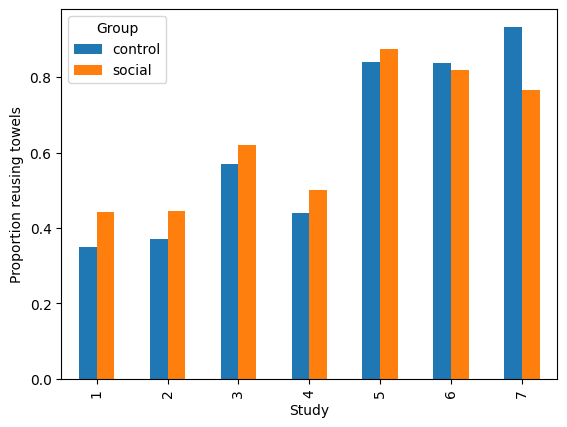

In [89]:
combined_data['proportion'] = combined_data['reuse'] / combined_data['total']

#reshape so control/social are next to each other for each study
plot_data = combined_data.pivot(index='study', columns='group', values='proportion')

#grouped bar chart
plot_data.plot(kind='bar')

plt.xlabel('Study')
plt.ylabel('Proportion reusing towels')
plt.legend(title='Group')

plt.show()


##Bar Chart

The figure shows the observed proportion of customers who reused their towels in the control and social groups for the seven studies.

The proportion of towel reuse is higher in the social group for studies 1–5, but lower for studies 6 and 7. This suggests that the effect of the intervention may differ between studies. There is also substantial variation in the overall proportion of towel reuse, with studies 1 and 2 having much lower reuse proportions than studies 5–7. This suggests between-study heterogeneity in the baseline probability of towel reuse.

This motivates a hierarchical model in which both the baseline towel-reuse probability and the intervention effect are allowed to vary between studies.


## Model choice and justification

The response variable is chosen as the number of customers who reuse their towels out of the total number of customers in each group and study. Therefore, a binomial model is the most suitable option.

For group $i$ in study $j$:

$$
Y_{ij} \sim \mathrm{Binomial}(N_{ij}, p_{ij})
$$

where:

- $Y_{ij}$ is the number of customers who reuse their towels,
- $N_{ij}$ is the total number of customers,
- $p_{ij}$ is the probability of towel reuse.

Because $p_{ij}$ is a probability restricted to values between 0 and 1, a logit link is used:

$$
\mathrm{logit}(p_{ij})
=
\log\left(\frac{p_{ij}}{1-p_{ij}}\right)
$$

The hierarchical logistic model is:

$$
\mathrm{logit}(p_{ij})
=
\beta_0
+
\beta_{\mathrm{social}}x_{ij}
+
u_{0j}
+
u_{1j}x_{ij}
$$

where:

$$
x_{ij} =
\begin{cases}
0, & \text{control group} \\
1, & \text{social group}
\end{cases}
$$

The parameter $\beta_0$ represents the overall baseline of towel reuse in the control group.

The parameter $\beta_{\mathrm{social}}$ represents the overall average effect of the social intervention on towel reuse.

The random intercept is:

$$
u_{0j} \sim N(0,\sigma_0^2)
$$

It allows the baseline towel-reuse probability to vary between studies.

The random slope is:

$$
u_{1j} \sim N(0,\sigma_1^2)
$$

It allows the effect of the social intervention to vary between studies.


In [90]:
random_seed = 1234

model_hierarchical = bmb.Model("p(reuse, total) ~ group + (1 + group | study)", combined_data, family="binomial")
idata_hierarchical = model_hierarchical.fit(random_seed=random_seed)

Output()

ERROR:pymc.stats.convergence:There were 16 divergences after tuning. Increase `target_accept` or reparameterize.


The Bayesian hierarchical model was fitted using MCMC sampling through bambi. The model generated posterior samples for the parameters, but the first run resulted in 16 divergences, so the model specification and priors must be examined before using the posterior results.


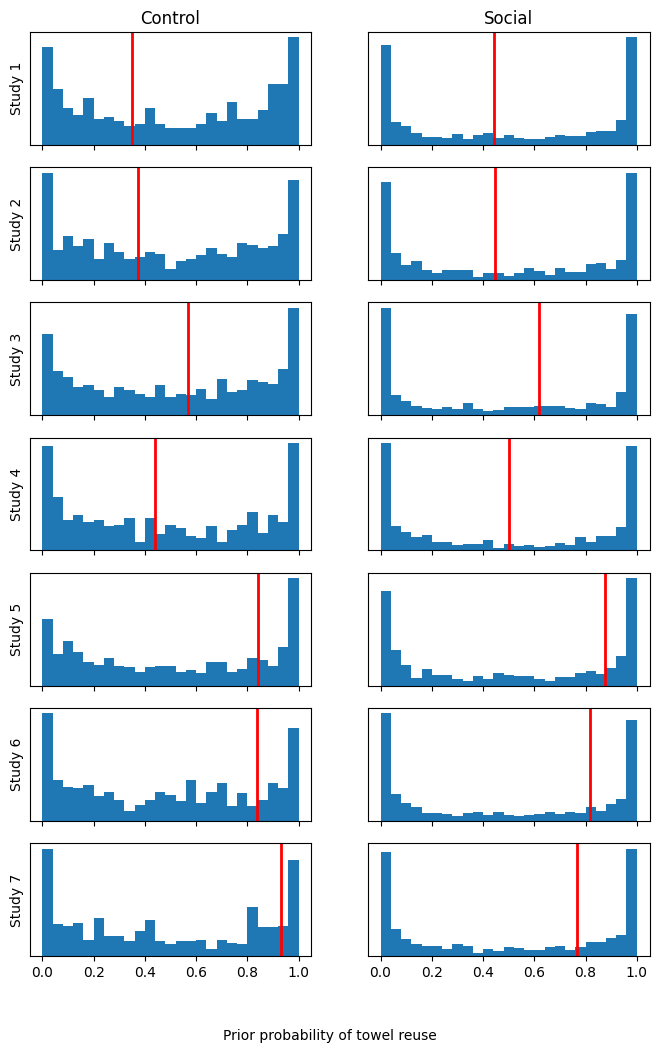

In [91]:
idata_prior = model_hierarchical.prior_predictive()
prior = az.extract(idata_prior, group="prior_predictive")

def plot_prior_predictive(df, prior):

    fig, axes = plt.subplots(7, 2, figsize=(8, 12), sharex=True)

    groups = ['control', 'social']

    for study in range(1, 8):

        for j, group in enumerate(groups):

            #find the corresponding row in combined_data
            idx = df[(df['study'].astype(int) == study) & (df['group'] == group)].index[0]

            total = df.loc[idx, 'total']
            reuse = df.loc[idx, 'reuse']

            #simulated reuse counts from prior predictive
            pps = prior.sel(__obs__=idx)

            ax = axes[study - 1, j]

            #convert counts to proportions
            ax.hist(pps / total, bins=25)

            #observed reuse proportion
            ax.axvline(reuse / total, color='red', lw=2)

            ax.set_yticks([])

            if study == 1:
                ax.set_title(group.capitalize())

            if j == 0:
                ax.set_ylabel(f'Study {study}')

    fig.text(
        0.5, 0.04,
        'Prior probability of towel reuse', ha='center')

    plt.show()

plot_prior_predictive(combined_data, prior)

In [92]:
print(model_hierarchical)

       Formula: p(reuse, total) ~ group + (1 + group | study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))
            group|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 5.0))
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()


From the plots, it can be seen that the prior predictive distributions produced by the default Bambi priors are extremely broad, with a large amount of probability close to both 0 and 1. This means that before seeing the data, the model considers towel-reuse probabilities being either 0% or 100% quite plausible, which is unrealistic for this project. Therefore, the priors are adjusted.

Output()

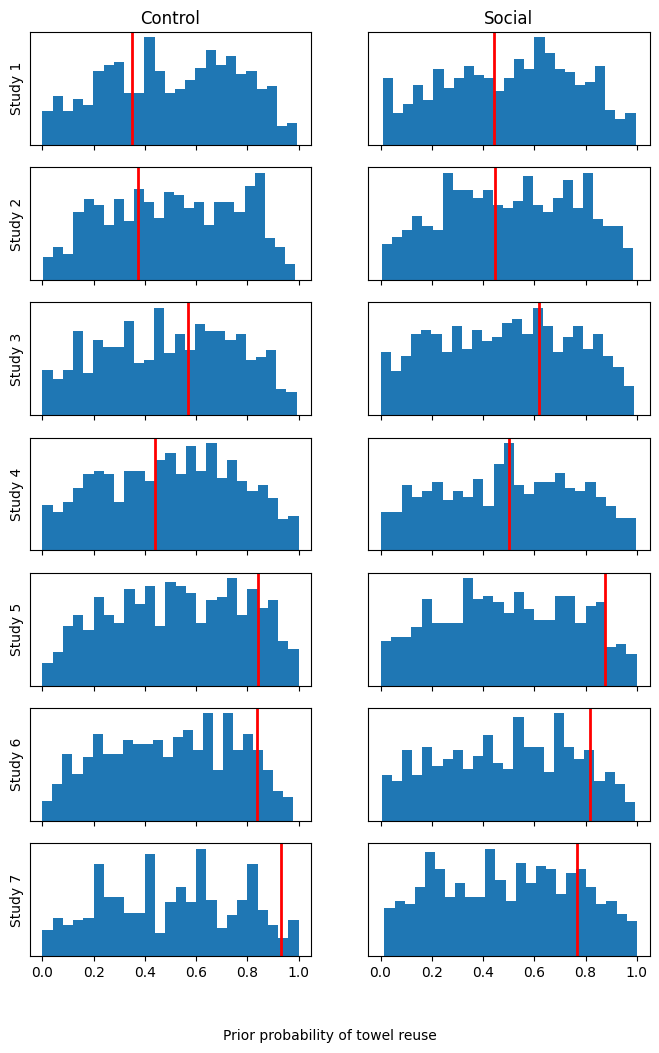

In [93]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1),
    "group": bmb.Prior("Normal", mu=0, sigma=0.5),
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=0.8)),
    "group|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=0.5))}

model_hierarchical = bmb.Model("p(reuse, total) ~ group + (1 + group | study)", combined_data, family="binomial", priors=priors)
idata_hierarchical = model_hierarchical.fit(tune=2000, draws=2000, target_accept=0.95, random_seed=random_seed)

idata_prior = model_hierarchical.prior_predictive()
prior = az.extract(idata_prior, group="prior_predictive")
plot_prior_predictive(combined_data, prior)

After adjusting the priors and changing target acceptance to 0.95, the divergence warnings disappear. The prior predictive distributions are now much less concentrated at probabilities of 0 and 1. They still cover a wide range of possible towel-reuse probabilities, allowing differences between studies, but no longer strongly favor unrealistic extremes. Therefore, these priors were considered a more reasonable specification for the final model.

In [94]:
az.summary(idata_hierarchical, ci_prob=0.90)

,mean,sd,eti90_lb,eti90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.42,0.37,-0.17,1,1002,1348,1.00,0.012,0.0089
group[social],0.175,0.121,-0.031,0.35,2260,1772,1.00,0.0028,0.0039
1|study_sigma,0.97,0.26,0.63,1.5,1499,1990,1.00,0.0067,0.007
group|study_sigma[social],0.152,0.132,0.011,0.42,1367,1635,1.00,0.0034,0.0038
1|study[1],-0.95,0.38,-1.6,-0.36,1051,1377,1.00,0.012,0.0088
1|study[2],-0.88,0.38,-1.5,-0.28,1025,1441,1.00,0.012,0.0084
1|study[3],-0.12,0.38,-0.74,0.5,1028,1380,1.00,0.012,0.0081
1|study[4],-0.63,0.38,-1.3,-0.021,1033,1506,1.00,0.012,0.0089
1|study[5],1.11,0.49,0.35,1.9,1771,2210,1.00,0.012,0.0079
1|study[6],1.02,0.38,0.4,1.6,1055,1601,1.00,0.012,0.0081


##Summary of Parameter Values

The model intercept had a posterior mean of \(0.42\), with a 90% probability interval of $[-0.16, 0.99]$.

The social-norm intervention effect had a posterior mean of $0.173$, with a 90% probability interval of $[-0.0016, 0.32]$. This suggests that the intervention is generally associated with more towel reuse, although the interval just includes zero.

There was a lot of variation in towel-reuse levels between studies ($\sigma_0 = 0.95$), while the intervention effect varied much less between studies ($\sigma_1 = 0.124$).

##Hypothesis for effectiveness of intervention

The intervention is meant to increase towel reuse therefore we can use a directional hypothesis.

H0: β_social ≤ 0

H1: β_social > 0


where H0 : the social intervention does not increase towel reuse
and H1 : the social intervention increases towel reuse.



In [95]:
beta_social = idata_hierarchical.posterior["group"].squeeze()
p_positive = (beta_social > 0).mean().item()
print("P(beta_social > 0 | data) =", p_positive)

p_nonpositive = (beta_social <= 0).mean().item()

print("P(beta_social <= 0 | data) =", p_nonpositive)
print(p_positive + p_nonpositive)

P(beta_social > 0 | data) = 0.92725
P(beta_social <= 0 | data) = 0.07275
1.0


The posterior probability of a positive intervention effect was \(0.9475\), while the probability of a non-positive effect was \(0.0525\). The posterior therefore strongly favors a positive average intervention effect, although there remains about a 5.3% posterior probability that the effect is not positive.